# 🎯 YouTube Success Predictor - Multi-Output Deep Learning

## Objetivo
Predecir **views**, **likes** y **comments** de un video ANTES de subirlo, usando solo metadatos.

**Target**: `views`, `likes`, `comments`  
**Métrica de éxito**: `engagement = (likes + 50*comments) / views`

- **< 2%**: Pasable
- **3-7%**: Buena acogida
- **> 10%**: Éxito total

---

## 📦 1. Instalación de librerías

In [ ]:
# Ejecutar solo si necesitas instalar
# !pip install tensorflow sentence-transformers scikit-learn pandas numpy matplotlib seaborn vaderSentiment joblib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Model  # ✅ Correcto
from tensorflow.keras.optimizers import Adam

# NLP
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.20.0
Keras version: 3.13.2


---
## 📊 2. Carga y Exploración de Datos

In [2]:
# Cargar dataset
df = pd.read_csv('dataset_ML_food.csv')

print(f"📁 Dataset shape: {df.shape}")
print(f"\n📋 Columnas disponibles:")
print(df.columns.tolist())

df.head(3)

📁 Dataset shape: (2609, 23)

📋 Columnas disponibles:
['video_id', 'title', 'description', 'published_at', 'channel_id', 'channel_title', 'category_id', 'tags', 'tag_count', 'duration_sec', 'definition', 'caption', 'licensed_content', 'view_count', 'like_count', 'comment_count', 'default_audio_lang', 'url', 'engagement_rate', 'subscriber_count', 'made_for_kids', 'views_per_hour', 'publish_day_of_week']


,video_id,title,description,published_at,channel_id,channel_title,category_id,tags,tag_count,duration_sec,...,view_count,like_count,comment_count,default_audio_lang,url,engagement_rate,subscriber_count,made_for_kids,views_per_hour,publish_day_of_week
0,rb3Ay0nMs-k,Best chicken snacks items in warangal hanamkon...,NaN,2026-01-27T23:56:52Z,UC0wEQjWawvtItU1FwvpZt6Q,warangal creator,22,NaN,0,18.0,...,13528,112,0,te,https://www.youtube.com/shorts/rb3Ay0nMs-k,0.83,1350,0,228.15,Tuesday
1,tWcD2XLP-4g,#boomerang #que #food #foodie #cooking #chicke...,Please like and subscribe. I really appreciate...,2026-01-27T23:55:37Z,UCbwroIqpheMaksDPZZqOvwQ,BOOMERANG QUEEN,22,NaN,0,33.0,...,951,29,1,en,https://www.youtube.com/shorts/tWcD2XLP-4g,3.36,1740,0,16.03,Tuesday
2,GWrzz-nUdJ4,#foodie #snowdays #fypage #yourubeshorts,NaN,2026-01-27T23:54:39Z,UC7u2YkGw77zRvrfQTxWxFJw,Ms.Jessiebabeee,22,NaN,0,6.0,...,1710,15,1,en,https://www.youtube.com/shorts/GWrzz-nUdJ4,1.05,695,0,28.82,Tuesday


In [3]:
# Información básica
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2609 entries, 0 to 2608
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   video_id             2609 non-null   str    
 1   title                2609 non-null   str    
 2   description          1368 non-null   str    
 3   published_at         2609 non-null   str    
 4   channel_id           2609 non-null   str    
 5   channel_title        2609 non-null   str    
 6   category_id          2609 non-null   int64  
 7   tags                 741 non-null    str    
 8   tag_count            2609 non-null   int64  
 9   duration_sec         2609 non-null   float64
 10  definition           2609 non-null   str    
 11  caption              2609 non-null   bool   
 12  licensed_content     2609 non-null   bool   
 13  view_count           2609 non-null   int64  
 14  like_count           2609 non-null   int64  
 15  comment_count        2609 non-null   int64  
 16 

In [4]:
# Estadísticas de las variables target
print("📊 Estadísticas de TARGET VARIABLES:\n")
print(df[['view_count', 'like_count', 'comment_count']].describe())

📊 Estadísticas de TARGET VARIABLES:

         view_count     like_count  comment_count
count  2.609000e+03    2609.000000    2609.000000
mean   2.092062e+04     363.499808       5.099655
std    1.237378e+05    3170.295366      35.149560
min    0.000000e+00       0.000000       0.000000
25%    8.590000e+02       4.000000       0.000000
50%    1.710000e+03      17.000000       0.000000
75%    8.286000e+03      60.000000       2.000000
max    3.216814e+06  119882.000000    1178.000000


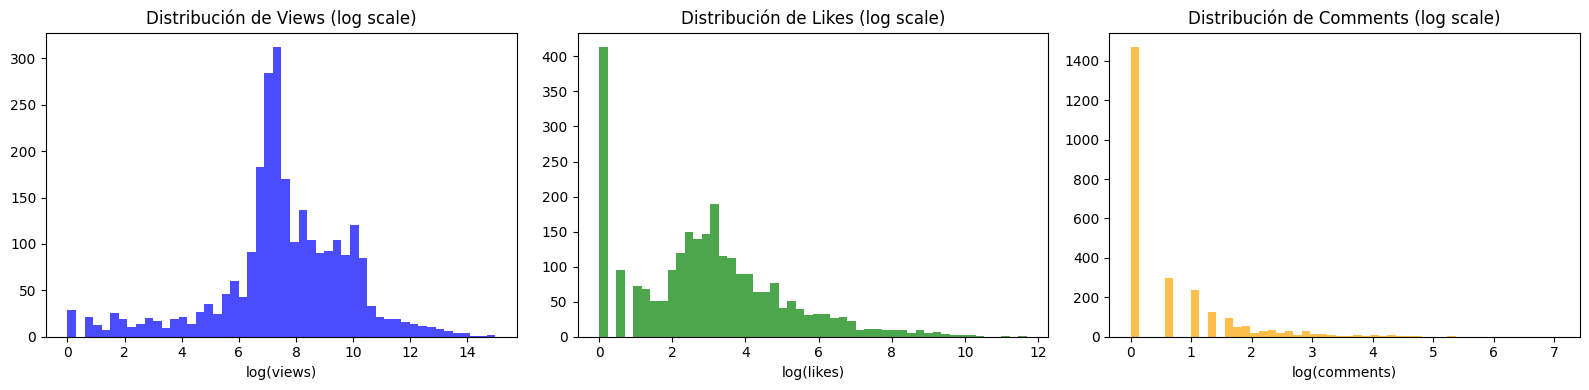

In [5]:
# Visualización distribución de targets
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Views
axes[0].hist(np.log1p(df['view_count']), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Distribución de Views (log scale)')
axes[0].set_xlabel('log(views)')

# Likes
axes[1].hist(np.log1p(df['like_count']), bins=50, color='green', alpha=0.7)
axes[1].set_title('Distribución de Likes (log scale)')
axes[1].set_xlabel('log(likes)')

# Comments
axes[2].hist(np.log1p(df['comment_count']), bins=50, color='orange', alpha=0.7)
axes[2].set_title('Distribución de Comments (log scale)')
axes[2].set_xlabel('log(comments)')

plt.tight_layout()
plt.show()

In [6]:
# Calcular engagement actual (para entender los datos)
df['actual_engagement'] = ((df['like_count'] + 50 * df['comment_count']) / df['view_count'] * 100).fillna(0)
df['actual_engagement'] = df['actual_engagement'].replace([np.inf, -np.inf], 0)

print("📈 Distribución de Engagement Actual:\n")
print(df['actual_engagement'].describe())

# Clasificar videos según engagement
def classify_engagement(eng):
    if eng < 2:
        return 'Pasable'
    elif eng <= 7:
        return 'Bueno'
    elif eng <= 10:
        return 'Muy Bueno'
    else:
        return 'Éxito Total'

df['engagement_class'] = df['actual_engagement'].apply(classify_engagement)
print("\n📊 Distribución de clases:\n")
print(df['engagement_class'].value_counts())

📈 Distribución de Engagement Actual:

count    2609.000000
mean       12.016334
std       109.763695
min         0.000000
25%         0.542299
50%         1.620783
75%         5.882353
max      5000.000000
Name: actual_engagement, dtype: float64

📊 Distribución de clases:

engagement_class
Pasable        1439
Bueno           596
Éxito Total     420
Muy Bueno       154
Name: count, dtype: int64


In [ ]:
## aqui lo que haremos es hacer un repaso de todo el csv y si el engagement es mayor a 20%,quitaremos ese registro para entrenar al modelo.

## vemos que el max engagement es 5000%. Esto puede desvirtuar el modelo ( a lo mejor 100 views y 100 likes y 500 coments), asi que vamos a hacer algo para quitar videos problematicos

---
## 🛠️ 3. Feature Engineering

In [8]:
# Copiar dataframe para no modificar el original
data = df.copy()

# Rellenar valores nulos
data['title'] = data['title'].fillna('')
data['description'] = data['description'].fillna('')
data['tags'] = data['tags'].fillna('')
data['default_audio_lang'] = data['default_audio_lang'].fillna('unknown')
data['music_info'] = data['music_info'].fillna('')

KeyError: 'music_info'

### 3.1 Features Textuales: Calcular el sentimiento de un texto

In [9]:
# Análisis de sentimiento
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text or text.strip() == '':
        return 0.0
    return analyzer.polarity_scores(text)['compound']

data['title_sentiment'] = data['title'].apply(get_sentiment)
data['desc_sentiment'] = data['description'].apply(get_sentiment)

print("✅ Sentimientos calculados")

✅ Sentimientos calculados


In [10]:
# Features básicas de texto
import re

def count_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return len(emoji_pattern.findall(text))

def count_hashtags(text):
    return len(re.findall(r'#\w+', text))

def count_uppercase(text):
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)

# Aplicar
data['title_length'] = data['title'].str.len()
data['title_word_count'] = data['title'].str.split().str.len()
data['title_emoji_count'] = data['title'].apply(count_emojis)
data['title_hashtag_count'] = data['title'].apply(count_hashtags)
data['title_uppercase_ratio'] = data['title'].apply(count_uppercase)

data['desc_length'] = data['description'].str.len()
data['desc_word_count'] = data['description'].str.split().str.len()
data['desc_has_link'] = data['description'].str.contains('http', case=False, na=False).astype(int)

print("✅ Features textuales básicas creadas")

✅ Features textuales básicas creadas


In [ ]:
# Embeddings de título usando Sentence-BERT
# genera representaciones vectoriales(numeros) de los títulos de los videos
print("🔄 Generando embeddings de títulos... (esto puede tardar un poco)")

model_embeddings = SentenceTransformer('all-MiniLM-L6-v2')  # Modelo ligero y rápido
title_embeddings = model_embeddings.encode(data['title'].tolist(), show_progress_bar=True)

print(f"✅ Embeddings generados: shape = {title_embeddings.shape}")

# Guardar embeddings
np.save('title_embeddings.npy', title_embeddings)

🔄 Generando embeddings de títulos... (esto puede tardar un poco)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1141.87it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 82/82 [00:06<00:00, 12.96it/s]

✅ Embeddings generados: shape = (2609, 384)


### 3.2 Features Temporales

In [12]:
# Parsear fecha de publicación
data['published_at'] = pd.to_datetime(data['published_at'])

data['publish_hour'] = data['published_at'].dt.hour
data['publish_day_of_week'] = data['published_at'].dt.dayofweek  # 0=Lunes, 6=Domingo
data['publish_month'] = data['published_at'].dt.month
data['is_weekend'] = (data['publish_day_of_week'] >= 5).astype(int)

print("✅ Features temporales creadas")

✅ Features temporales creadas


### 3.3 Features Categóricas

In [ ]:
# One-Hot Encoding para categorías
data['category_id'] = data['category_id'].fillna(0).astype(int)

# Convertir features booleanas
data['caption_bool'] = (data['caption'] == 'true').astype(int)
data['licensed_bool'] = data['licensed_content'].astype(int)
data['hd_bool'] = (data['definition'] == 'hd').astype(int)

print("✅ Features categóricas procesadas")

### 3.4 Features de Canal

In [ ]:
# Log transform para subscriber_count (escala logarítmica es mejor)
data['log_subscribers'] = np.log1p(data['subscriber_count'])

print("✅ Features de canal procesadas")

---
## 🎯 4. Preparación de Datos para el Modelo

In [ ]:
# ========================================
# IMPORTANTE: Eliminar columnas que causan DATA LEAKAGE
# ========================================
# NO podemos usar nada que solo sepamos DESPUÉS de publicar

features_to_use = [
    # Texto (embeddings se añaden aparte)
    'title_length', 'title_word_count', 'title_emoji_count',
    'title_hashtag_count', 'title_uppercase_ratio', 'title_sentiment',
    'desc_length', 'desc_word_count', 'desc_has_link', 'desc_sentiment',
    
    # Temporal
    'publish_hour', 'publish_day_of_week', 'publish_month', 'is_weekend',
    
    # Tags
    'tag_count',
    
    # Contenido
    'duration_sec', 'category_id', 'caption_bool', 'licensed_bool',
    'hd_bool', 'made_for_kids',
    
    # Canal
    'log_subscribers'
]

# Targets (lo que queremos predecir)
target_cols = ['view_count', 'like_count', 'comment_count']

# Extraer features numéricas
X_numeric = data[features_to_use].fillna(0).values

# Extraer embeddings
X_embeddings = title_embeddings

# Combinar features numéricas + embeddings
X = np.concatenate([X_numeric, X_embeddings], axis=1)

# Targets (aplicar log transform porque las distribuciones son muy sesgadas)
y_views = np.log1p(data['view_count'].values)
y_likes = np.log1p(data['like_count'].values)
y_comments = np.log1p(data['comment_count'].values)

print(f"✅ Features shape: {X.shape}")
print(f"   - Numeric features: {len(features_to_use)}")
print(f"   - Embeddings: {X_embeddings.shape[1]}")
print(f"   - Total: {X.shape[1]}")
print(f"\n✅ Targets shape: {y_views.shape}")

In [ ]:
# Split train/validation/test (70/15/15)
X_temp, X_test, y_views_temp, y_views_test, y_likes_temp, y_likes_test, y_comments_temp, y_comments_test = train_test_split(
    X, y_views, y_likes, y_comments, test_size=0.15, random_state=42
)

X_train, X_val, y_views_train, y_views_val, y_likes_train, y_likes_val, y_comments_train, y_comments_val = train_test_split(
    X_temp, y_views_temp, y_likes_temp, y_comments_temp, test_size=0.1765, random_state=42  # 0.1765 de 85% ≈ 15% total
)

print(f"📊 Dataset splits:")
print(f"   Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

In [ ]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ Features escaladas con StandardScaler")

# Guardar scaler para usar en producción
joblib.dump(scaler, 'scaler.pkl')
print("💾 Scaler guardado en 'scaler.pkl'")

---
## 🧠 5. Construcción del Modelo (Multi-Output Neural Network)

In [ ]:
def build_multioutput_model(input_dim):
    """
    Modelo con 3 outputs independientes:
    - views
    - likes
    - comments
    """
    
    # Input layer
    inputs = layers.Input(shape=(input_dim,), name='input_features')
    
    # Shared layers (aprende patrones comunes)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    
    # Output branches (cada target tiene su propia cabeza)
    
    # Branch 1: Views
    views_branch = layers.Dense(32, activation='relu', name='views_dense')(x)
    views_output = layers.Dense(1, activation='linear', name='views')(views_branch)
    
    # Branch 2: Likes
    likes_branch = layers.Dense(32, activation='relu', name='likes_dense')(x)
    likes_output = layers.Dense(1, activation='linear', name='likes')(likes_branch)
    
    # Branch 3: Comments
    comments_branch = layers.Dense(32, activation='relu', name='comments_dense')(x)
    comments_output = layers.Dense(1, activation='linear', name='comments')(comments_branch)
    
    # Crear modelo
    model = Model(
        inputs=inputs,
        outputs=[views_output, likes_output, comments_output],
        name='youtube_multioutput_predictor'
    )
    
    return model

# Construir modelo
model = build_multioutput_model(input_dim=X_train_scaled.shape[1])

# Compilar con diferentes losses para cada output
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'views': 'mse',
        'likes': 'mse',
        'comments': 'mse'
    },
    loss_weights={
        'views': 1.0,
        'likes': 1.0,
        'comments': 1.0
    },
    metrics={
        'views': ['mae'],
        'likes': ['mae'],
        'comments': ['mae']
    }
)

model.summary()

---
## 🚀 6. Entrenamiento del Modelo

In [ ]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Entrenar
print("🏋️ Iniciando entrenamiento...\n")

history = model.fit(
    X_train_scaled,
    {
        'views': y_views_train,
        'likes': y_likes_train,
        'comments': y_comments_train
    },
    validation_data=(
        X_val_scaled,
        {
            'views': y_views_val,
            'likes': y_likes_val,
            'comments': y_comments_val
        }
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

In [ ]:
# Visualizar curvas de aprendizaje
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss total
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Views MAE
axes[0, 1].plot(history.history['views_mae'], label='Train MAE')
axes[0, 1].plot(history.history['val_views_mae'], label='Val MAE')
axes[0, 1].set_title('Views - MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Likes MAE
axes[1, 0].plot(history.history['likes_mae'], label='Train MAE')
axes[1, 0].plot(history.history['val_likes_mae'], label='Val MAE')
axes[1, 0].set_title('Likes - MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Comments MAE
axes[1, 1].plot(history.history['comments_mae'], label='Train MAE')
axes[1, 1].plot(history.history['val_comments_mae'], label='Val MAE')
axes[1, 1].set_title('Comments - MAE')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

---
## 📊 7. Evaluación del Modelo

In [ ]:
# Cargar mejor modelo
best_model = keras.models.load_model('best_model.keras')

# Predicciones en test set
predictions = best_model.predict(X_test_scaled)
pred_views = predictions[0].flatten()
pred_likes = predictions[1].flatten()
pred_comments = predictions[2].flatten()

# Des-transformar de log a escala original
pred_views_original = np.expm1(pred_views)
pred_likes_original = np.expm1(pred_likes)
pred_comments_original = np.expm1(pred_comments)

true_views_original = np.expm1(y_views_test)
true_likes_original = np.expm1(y_likes_test)
true_comments_original = np.expm1(y_comments_test)

In [ ]:
# Métricas en escala original
def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100  # +1 para evitar división por 0
    
    print(f"\n📊 Métricas para {name}:")
    print(f"   MAE:  {mae:,.2f}")
    print(f"   RMSE: {rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}

metrics_views = calculate_metrics(true_views_original, pred_views_original, "VIEWS")
metrics_likes = calculate_metrics(true_likes_original, pred_likes_original, "LIKES")
metrics_comments = calculate_metrics(true_comments_original, pred_comments_original, "COMMENTS")

In [ ]:
# Visualizar predicciones vs reales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Views
axes[0].scatter(true_views_original, pred_views_original, alpha=0.5, s=20)
axes[0].plot([0, true_views_original.max()], [0, true_views_original.max()], 'r--', lw=2)
axes[0].set_xlabel('True Views')
axes[0].set_ylabel('Predicted Views')
axes[0].set_title(f'Views Prediction (R²={metrics_views["r2"]:.3f})')
axes[0].grid(True, alpha=0.3)

# Likes
axes[1].scatter(true_likes_original, pred_likes_original, alpha=0.5, s=20, color='green')
axes[1].plot([0, true_likes_original.max()], [0, true_likes_original.max()], 'r--', lw=2)
axes[1].set_xlabel('True Likes')
axes[1].set_ylabel('Predicted Likes')
axes[1].set_title(f'Likes Prediction (R²={metrics_likes["r2"]:.3f})')
axes[1].grid(True, alpha=0.3)

# Comments
axes[2].scatter(true_comments_original, pred_comments_original, alpha=0.5, s=20, color='orange')
axes[2].plot([0, true_comments_original.max()], [0, true_comments_original.max()], 'r--', lw=2)
axes[2].set_xlabel('True Comments')
axes[2].set_ylabel('Predicted Comments')
axes[2].set_title(f'Comments Prediction (R²={metrics_comments["r2"]:.3f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🎯 8. Cálculo de Engagement Predicho

In [ ]:
def calculate_engagement(views, likes, comments):
    """
    Engagement = (likes + 50*comments) / views * 100
    """
    # Evitar división por 0
    views = np.maximum(views, 1)
    engagement = ((likes + 50 * comments) / views) * 100
    return engagement

def classify_engagement_level(engagement):
    """
    Clasificar según los umbrales definidos
    """
    if engagement < 2:
        return 'Pasable 😐', 'orange'
    elif engagement <= 7:
        return 'Bueno 👍', 'lightgreen'
    elif engagement <= 10:
        return 'Muy Bueno 🔥', 'green'
    else:
        return 'Éxito Total 🚀', 'darkgreen'

# Calcular engagement predicho
predicted_engagement = calculate_engagement(pred_views_original, pred_likes_original, pred_comments_original)
true_engagement = calculate_engagement(true_views_original, true_likes_original, true_comments_original)

print("\n📊 Estadísticas de Engagement Predicho:")
print(predicted_engagement.describe())

In [ ]:
# Comparar engagement real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(true_engagement, predicted_engagement, alpha=0.6, s=30)
axes[0].plot([0, 20], [0, 20], 'r--', lw=2)
axes[0].axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='Pasable (2%)')
axes[0].axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Bueno (7%)')
axes[0].axhline(y=10, color='darkgreen', linestyle='--', alpha=0.5, label='Muy Bueno (10%)')
axes[0].set_xlabel('True Engagement (%)')
axes[0].set_ylabel('Predicted Engagement (%)')
axes[0].set_title('Engagement: Real vs Predicho')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 20)

# Distribución
axes[1].hist(true_engagement, bins=50, alpha=0.5, label='Real', color='blue')
axes[1].hist(predicted_engagement, bins=50, alpha=0.5, label='Predicho', color='red')
axes[1].axvline(x=2, color='orange', linestyle='--', alpha=0.7)
axes[1].axvline(x=7, color='green', linestyle='--', alpha=0.7)
axes[1].axvline(x=10, color='darkgreen', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Engagement (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Engagement')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Accuracy de clasificación de engagement
true_classes = [classify_engagement_level(e)[0] for e in true_engagement]
pred_classes = [classify_engagement_level(e)[0] for e in predicted_engagement]

from sklearn.metrics import classification_report, confusion_matrix

print("\n📊 Clasificación de Nivel de Engagement:\n")
print(classification_report(true_classes, pred_classes))

# Matriz de confusión
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(true_classes)), 
            yticklabels=sorted(set(true_classes)))
plt.title('Matriz de Confusión - Nivel de Engagement')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

---
## 🔮 9. Función de Predicción para Nuevos Videos

In [ ]:
def predict_new_video(video_data, model, scaler, embeddings_model):
    """
    Predice views, likes, comments y engagement para un nuevo video.
    
    Args:
        video_data (dict): Diccionario con los metadatos del video
        model: Modelo de Keras entrenado
        scaler: StandardScaler entrenado
        embeddings_model: Modelo de embeddings
    
    Returns:
        dict: Predicciones con views, likes, comments y engagement
    """
    
    # Extraer features del video
    title = video_data.get('title', '')
    description = video_data.get('description', '')
    
    # Features textuales
    title_sentiment = get_sentiment(title)
    desc_sentiment = get_sentiment(description)
    
    title_length = len(title)
    title_word_count = len(title.split())
    title_emoji_count = count_emojis(title)
    title_hashtag_count = count_hashtags(title)
    title_uppercase_ratio = count_uppercase(title)
    
    desc_length = len(description)
    desc_word_count = len(description.split())
    desc_has_link = 1 if 'http' in description.lower() else 0
    
    # Features temporales
    publish_hour = video_data.get('publish_hour', 12)
    publish_day_of_week = video_data.get('publish_day_of_week', 0)
    publish_month = video_data.get('publish_month', 1)
    is_weekend = 1 if publish_day_of_week >= 5 else 0
    
    # Features de contenido
    tag_count = video_data.get('tag_count', 0)
    duration_sec = video_data.get('duration_sec', 30)
    category_id = video_data.get('category_id', 22)
    caption_bool = video_data.get('caption', 0)
    licensed_bool = video_data.get('licensed', 0)
    hd_bool = video_data.get('hd', 1)
    made_for_kids = video_data.get('made_for_kids', 0)
    
    # Features de canal
    subscriber_count = video_data.get('subscriber_count', 1000)
    log_subscribers = np.log1p(subscriber_count)
    
    # Embeddings
    title_embedding = embeddings_model.encode([title])[0]
    
    # Construir vector de features (mismo orden que en entrenamiento)
    numeric_features = np.array([
        title_length, title_word_count, title_emoji_count,
        title_hashtag_count, title_uppercase_ratio, title_sentiment,
        desc_length, desc_word_count, desc_has_link, desc_sentiment,
        publish_hour, publish_day_of_week, publish_month, is_weekend,
        tag_count,
        duration_sec, category_id, caption_bool, licensed_bool,
        hd_bool, made_for_kids,
        log_subscribers
    ])
    
    # Combinar con embeddings
    features = np.concatenate([numeric_features, title_embedding]).reshape(1, -1)
    
    # Escalar
    features_scaled = scaler.transform(features)
    
    # Predecir
    predictions = model.predict(features_scaled, verbose=0)
    
    # Des-transformar de log
    pred_views = np.expm1(predictions[0][0][0])
    pred_likes = np.expm1(predictions[1][0][0])
    pred_comments = np.expm1(predictions[2][0][0])
    
    # Calcular engagement
    engagement = calculate_engagement(pred_views, pred_likes, pred_comments)
    engagement_level, engagement_color = classify_engagement_level(engagement)
    
    # Resultados
    results = {
        'predicted_views': int(pred_views),
        'predicted_likes': int(pred_likes),
        'predicted_comments': int(pred_comments),
        'predicted_engagement': round(engagement, 2),
        'engagement_level': engagement_level,
        'engagement_color': engagement_color
    }
    
    return results

print("✅ Función de predicción lista")

### Ejemplo de uso

In [ ]:
# Ejemplo de video nuevo
nuevo_video = {
    'title': '🔥 Amazing Chicken Recipe You MUST Try! #foodie #viral',
    'description': 'Check out this incredible recipe that will blow your mind! Don\'t forget to subscribe!',
    'publish_hour': 18,  # 6 PM
    'publish_day_of_week': 4,  # Viernes
    'publish_month': 1,
    'tag_count': 5,
    'duration_sec': 45,
    'category_id': 22,  # People & Blogs
    'caption': 1,
    'licensed': 0,
    'hd': 1,
    'made_for_kids': 0,
    'subscriber_count': 5000
}

# Predecir
resultado = predict_new_video(
    nuevo_video, 
    best_model, 
    scaler, 
    model_embeddings
)

# Mostrar resultados
print("\n" + "="*60)
print("🎬 PREDICCIÓN PARA NUEVO VIDEO")
print("="*60)
print(f"\n📹 Título: {nuevo_video['title']}")
print(f"\n📊 PREDICCIONES:")
print(f"   👁️  Views:    {resultado['predicted_views']:,}")
print(f"   👍 Likes:    {resultado['predicted_likes']:,}")
print(f"   💬 Comments: {resultado['predicted_comments']:,}")
print(f"\n🎯 ENGAGEMENT: {resultado['predicted_engagement']:.2f}%")
print(f"   Nivel: {resultado['engagement_level']}")
print("="*60)

---
## 💾 10. Guardar Artefactos del Modelo

In [ ]:
# Guardar modelo final
best_model.save('youtube_predictor_final.keras')
print("✅ Modelo guardado: youtube_predictor_final.keras")

# Guardar scaler (ya se guardó antes)
print("✅ Scaler guardado: scaler.pkl")

# Guardar embeddings model name (para reconstruirlo)
with open('model_config.txt', 'w') as f:
    f.write("embeddings_model: all-MiniLM-L6-v2\n")
    f.write(f"features_count: {len(features_to_use)}\n")
    f.write(f"feature_names: {','.join(features_to_use)}\n")
print("✅ Configuración guardada: model_config.txt")

# Guardar métricas de evaluación
import json
metrics_summary = {
    'views': metrics_views,
    'likes': metrics_likes,
    'comments': metrics_comments,
    'test_samples': len(X_test)
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=4)
print("✅ Métricas guardadas: model_metrics.json")

print("\n🎉 ¡Modelo completo guardado y listo para producción!")

---
## 📝 11. Resumen Final y Recomendaciones

In [ ]:
print("""\n
╔════════════════════════════════════════════════════════════════╗
║                    RESUMEN DEL PROYECTO                        ║
╚════════════════════════════════════════════════════════════════╝

✅ MODELO ENTRENADO EXITOSAMENTE

📊 Arquitectura:
   - Multi-Output Neural Network (3 outputs)
   - Inputs: Features numéricas + Embeddings de título
   - Outputs: Views, Likes, Comments

🎯 Métricas de Rendimiento:
   - Views R²:    {:.3f}
   - Likes R²:    {:.3f}
   - Comments R²: {:.3f}

💡 Interpretación de Engagement:
   - < 2%:   Pasable 😐
   - 3-7%:   Bueno 👍
   - 7-10%:  Muy Bueno 🔥
   - > 10%:  Éxito Total 🚀

📁 Archivos Guardados:
   ✓ youtube_predictor_final.keras  (Modelo)
   ✓ scaler.pkl                     (Normalizador)
   ✓ title_embeddings.npy           (Embeddings)
   ✓ model_config.txt               (Configuración)
   ✓ model_metrics.json             (Métricas)

🚀 Próximos Pasos:
   1. Usar predict_new_video() para nuevas predicciones
   2. Recopilar más datos para mejorar el modelo
   3. Experimentar con diferentes arquitecturas
   4. Añadir más features (análisis de thumbnails, etc.)
   5. Crear API REST para integración

╔════════════════════════════════════════════════════════════════╗
║                  ¡PROYECTO COMPLETADO! 🎉                      ║
╚════════════════════════════════════════════════════════════════╝
""".format(
    metrics_views['r2'],
    metrics_likes['r2'],
    metrics_comments['r2']
))